# From Pixels to Spikes: Encoding Static Images for Spiking Neural Networks

Spiking Neural Networks (SNNs) process information as **discrete spike events** over time, unlike traditional neural networks that process continuous-valued activations. But datasets like MNIST are static images — just a grid of pixel intensities. So how do we feed them into an SNN?

This notebook walks through:
1. **Loading and exploring** the MNIST dataset
2. **Normalizing** pixel values into probabilities
3. **Bernoulli encoding** — converting static images into spike trains
4. **Visualizing** the resulting spatiotemporal spike patterns

In [17]:
!pip install mplcyberpunk -q

In [18]:
import torch
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import mplcyberpunk
from torchvision import datasets
from torchvision.transforms import ToTensor
from IPython.display import display, HTML

## 1. Loading and Exploring MNIST

MNIST contains 60,000 training images of handwritten digits (0–9), each 28x28 pixels. Raw pixel values are integers in [0, 255].

In [19]:
data = datasets.MNIST(root="./data", train=True, download=True, transform=ToTensor())

print(f"Dataset size: {len(data)} images")
print(f"Image shape: {data[0][0].shape}  (channels, height, width)")
print(f"Pixel value range: [{data[0][0].min():.1f}, {data[0][0].max():.1f}]")
print(f"Labels: {sorted(set(data.targets.numpy()))}")

Dataset size: 60000 images
Image shape: torch.Size([1, 28, 28])  (channels, height, width)
Pixel value range: [0.0, 1.0]
Labels: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]


Let's look at a 3x3 grid of random samples from the dataset:

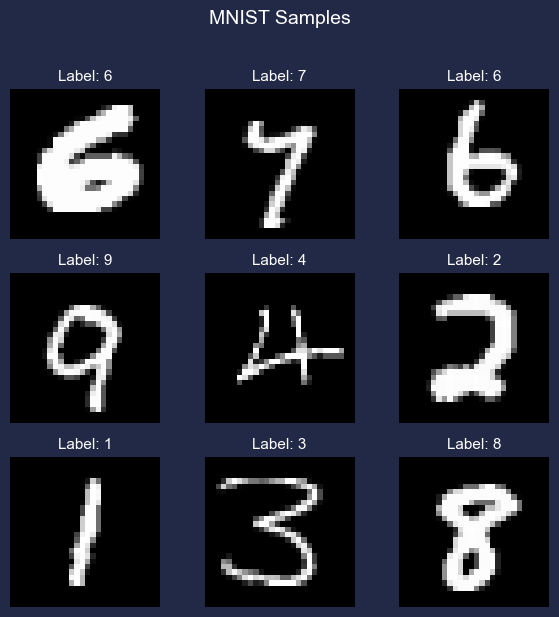

In [20]:
torch.manual_seed(42)
indices = torch.randperm(len(data))[:9]

with plt.style.context("cyberpunk"):
    fig, axes = plt.subplots(3, 3, figsize=(6, 6))
    for i, ax in enumerate(axes.flat):
        img, label = data[indices[i]]
        ax.imshow(img.squeeze(), cmap='gray')
        ax.set_title(f"Label: {label}", fontsize=11, color='white')
        ax.axis('off')
    fig.suptitle("MNIST Samples", fontsize=14, color='white', y=1.02)
    fig.tight_layout()
    plt.show()

## 2. Normalizing Pixel Values to Spike Probabilities

The `ToTensor()` transform already scales pixels from [0, 255] to [0.0, 1.0]. We can optionally apply an additional **scale factor** to control the overall firing rate. For example, `scale=0.8` means that even the brightest pixel will spike with probability 0.8 at each timestep rather than 1.0.

This scaling is important when using small simulation timesteps — a smaller `dt` means more timesteps, so we reduce the per-step spike probability to keep the total spike count reasonable.

In [21]:
# Normalize and scale the data
SCALE = 0.5

X = data.data.unsqueeze(1).float()  # (N, 1, 28, 28)
X /= X.max()                         # normalize to [0, 1]
X *= SCALE                           # scale to [0, 0.5]

# Pick a single sample to work with
sample_idx = 0
sample = X[sample_idx]  # shape: (1, 28, 28)

print(f"Tensor shape: {X.shape}")
print(f"Value range after scaling: [{X.min():.2f}, {X.max():.2f}]")
print(f"Each pixel value is now a probability of spiking at each timestep.")

Tensor shape: torch.Size([60000, 1, 28, 28])
Value range after scaling: [0.00, 0.50]
Each pixel value is now a probability of spiking at each timestep.


## 3. Bernoulli Encoding

The key idea is simple: **treat each pixel intensity as the probability of a spike**.

At every simulation timestep, we independently sample a Bernoulli random variable for each pixel:

$$S_{i,t} \sim \text{Bernoulli}(p_i)$$

where $p_i$ is the normalized pixel intensity. This means:
- **Bright pixels** (high $p_i$) spike frequently
- **Dark pixels** (low $p_i$) rarely spike
- **Black pixels** ($p_i = 0$) never spike

Each timestep produces a fresh random sample, so the same image generates a **different spike pattern** every time — just like biological neurons, which respond stochastically to the same stimulus.

Let's compare the original image with a single Bernoulli sample:

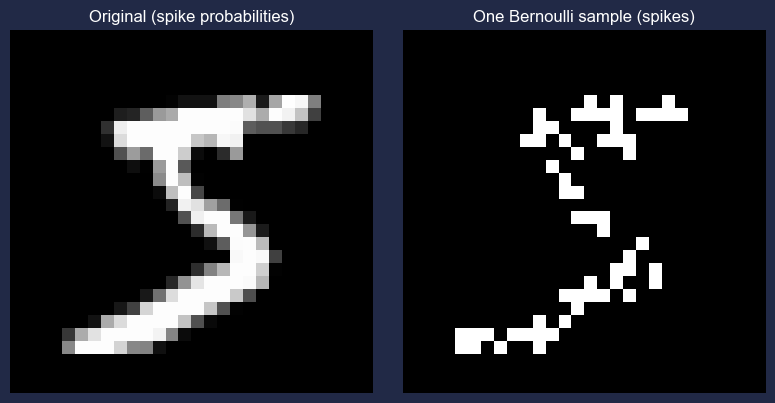

Original — unique values: 85, non-zero pixels: 166
Spikes   — unique values: 2 (binary!), active pixels: 58


In [22]:
with plt.style.context("cyberpunk"):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4))

    # Original image (probabilities)
    ax1.imshow(sample.squeeze(), cmap='gray')
    ax1.set_title("Original (spike probabilities)", color='white')
    ax1.axis('off')

    # Single Bernoulli sample (spikes)
    torch.manual_seed(1)
    spikes = torch.bernoulli(sample)
    ax2.imshow(spikes.squeeze(), cmap='gray')
    ax2.set_title("One Bernoulli sample (spikes)", color='white')
    ax2.axis('off')

    fig.tight_layout()
    plt.show()

print(f"Original \u2014 unique values: {sample.unique().numel()}, non-zero pixels: {(sample > 0).sum().item()}")
print(f"Spikes   \u2014 unique values: {spikes.unique().numel()} (binary!), active pixels: {spikes.sum().item():.0f}")

## 4. Spike Trains Over Time

In an SNN, we present the image over multiple timesteps. At each timestep, we independently sample spikes from the same probability map. This creates a **spike train** — a binary spatiotemporal pattern.

Let's flatten the 28x28 image into 784 input neurons and visualize the spike raster across 50 timesteps. Each row is a neuron (pixel), each column is a timestep, and white dots indicate spikes.

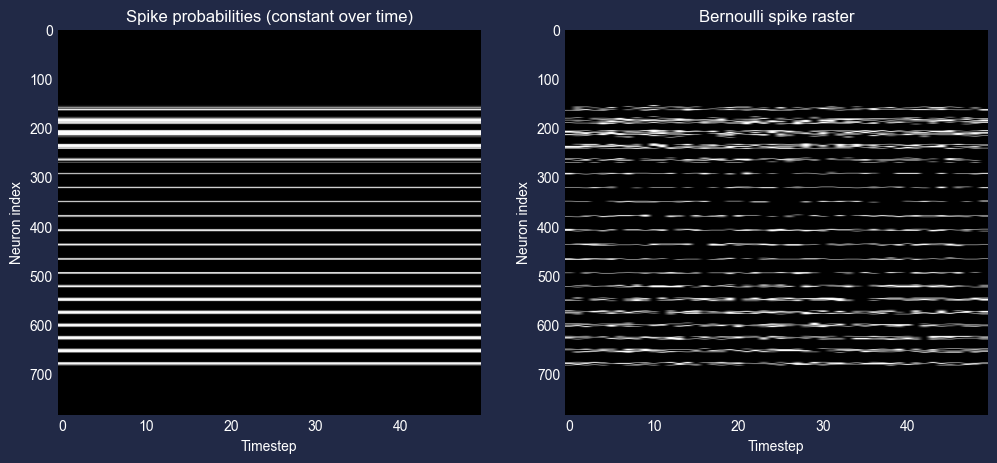

Total spikes: 2676 out of 8300 possible spike opportunities
Average firing rate: 6.8% per neuron per timestep


In [23]:
NUM_STEPS = 50

# Flatten sample to 784 neurons and repeat across timesteps
sample_flat = sample.view(1, 784)                          # (1, 784)
prob_tensor = sample_flat.unsqueeze(0).expand(NUM_STEPS, -1, -1)  # (50, 1, 784)

# Sample spikes at every timestep
torch.manual_seed(42)
input_spikes = torch.bernoulli(prob_tensor)

# Visualize: probabilities vs spikes
with plt.style.context("cyberpunk"):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    ax1.imshow(prob_tensor.squeeze(1).T, aspect='auto', cmap='gray')
    ax1.set_xlabel("Timestep", color='white')
    ax1.set_ylabel("Neuron index", color='white')
    ax1.set_title("Spike probabilities (constant over time)", color='white')
    ax1.tick_params(colors='white')
    ax1.grid(False)

    ax2.imshow(input_spikes.squeeze(1).T, aspect='auto', cmap='gray')
    ax2.set_xlabel("Timestep", color='white')
    ax2.set_ylabel("Neuron index", color='white')
    ax2.set_title("Bernoulli spike raster", color='white')
    ax2.tick_params(colors='white')
    ax2.grid(False)

    plt.show()

total_possible = (prob_tensor > 0).sum().item()
total_spikes = input_spikes.sum().item()
print(f"Total spikes: {total_spikes:.0f} out of {total_possible} possible spike opportunities")
print(f"Average firing rate: {total_spikes / (784 * NUM_STEPS) * 100:.1f}% per neuron per timestep")

## 5. Animated Spike Visualization

Each frame below shows a single timestep's spike pattern reshaped back to 28x28. Notice how the overall digit shape is preserved, but the exact pattern of active pixels changes from frame to frame — this is the stochastic nature of Bernoulli encoding.

In [24]:
with plt.style.context("cyberpunk"):
    fig, ax = plt.subplots(figsize=(4, 4))
    im = ax.imshow(input_spikes[0].squeeze().reshape(28, 28), cmap='gray')
    ax.axis('off')

    def update(frame):
        im.set_array(input_spikes[frame].squeeze().reshape(28, 28))
        ax.set_title(f"Timestep {frame + 1}/{NUM_STEPS}", color='white')
        return [im]

    ani = animation.FuncAnimation(fig, update, frames=NUM_STEPS, interval=100)
    display(HTML(ani.to_jshtml()))
    plt.close()

## Summary

**Bernoulli encoding** is one of the simplest ways to convert static data into spike trains:

| Property | Description |
|---|---|
| **Input** | Pixel intensities normalized to [0, 1] |
| **Output** | Binary spike train (0 or 1) per pixel per timestep |
| **Mechanism** | Independent Bernoulli sampling at each timestep |
| **Rate coding** | Brighter pixels fire more often on average |
| **Stochastic** | Same image produces different spike patterns each time |

**Advantages:** Simple, parameter-free (beyond the scale factor), preserves spatial structure.

**Limitations:** No temporal structure in the encoding itself — all temporal dynamics come from the network. More sophisticated encodings (e.g., latency coding, population coding) can embed richer temporal information.